In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import sys
import os
sys.path.append(os.path.abspath('..')) # Go up one level to the project root and add it to the path
from src.utils.config import get_data_path
from src.etl.ingest import load_nvdrs
from src.etl.transform import filter_nvdrs_suicides, aggregate_nvdrs_daily, aggregate_nvdrs_daily_injury, aggregate_nvdrs_monthly

In [ ]:
# manual downlad from
# https://wonder.cdc.gov/mcd.html
#
# ICD10 filter: X60-X84, Y87.0, and U03)

# I downladed from WONDER the state level deaths form 1999-2020 and 2021-2024 : raw  files in data/raw
# I combined them and removed notes in data/processed/WONDER_state_99-24.csv

# TODO: hcup 
# TODO: start looking at smaller scales. eventually finding ways to detectct anomalies of suicide clusters that go above the noise

# https://www.cdc.gov/mmwr/volumes/74/ss/ss7405a1.htm -> For 2022, a total of 50 states 
# (47 states collecting statewide data, 32 California counties, 32 Florida counties, and 13 Texas counties) and the District of Columbia 
# collected NVDRS data on 44,880 incidents involving 44,917 suicides (Supplementary Table 1). 
# The overall suicide rate was 14.8 per 100,000 population (Table 1).



In [2]:
#check differences with NVDRS
wnd_path = get_data_path('wonder_state', 'processed')
wnd_df=pd.read_csv(wnd_path)
wnd_df['Date'] = pd.to_datetime(wnd_df['Month Code'], format='%Y/%m') + pd.offsets.MonthEnd(0)
wnd_df= wnd_df.pivot(index='Date', columns='State', values='Deaths')


if 'nvdrs_df' not in locals():
    usemincol = ['IncidentID','InjuryDate','InjuryState','InjuryFIPS','DeathDate', 'DeathDate_myr', 'DeathDate_year', 'DeathState', 'DeathFIPS', 'IncidentCategory_c','PersonType'] 
    nvdrs_df = load_nvdrs(file_key="nvdrs", data_folder="raw", usecols=usemincol)
    
# Filter suicides
nvdrs_df = filter_nvdrs_suicides(nvdrs_df)

# 1. Death Date (Daily resampled to Monthly)
nvdrs_df_death = nvdrs_df[nvdrs_df['DeathDate'] >= '2010-01-01']
nvdrs_df_death = aggregate_nvdrs_daily(nvdrs_df_death, geo_level='state').set_index('DeathDate').resample('ME').sum()

# 2. Injury Date (Daily resampled to Monthly)
nvdrs_df_injury = nvdrs_df[nvdrs_df['InjuryDate'] >= '2010-01-01']
nvdrs_df_injury = aggregate_nvdrs_daily_injury(nvdrs_df_injury, geo_level='state').set_index('InjuryDate').resample('ME').sum()

# 3. Death Month (Directly aggregated by Month)
nvdrs_df_month = nvdrs_df[nvdrs_df['DeathDate_myr'] >= '2010-01-01']
nvdrs_df_month = aggregate_nvdrs_monthly(nvdrs_df_month, geo_level='state').set_index('DeathDate_myr')


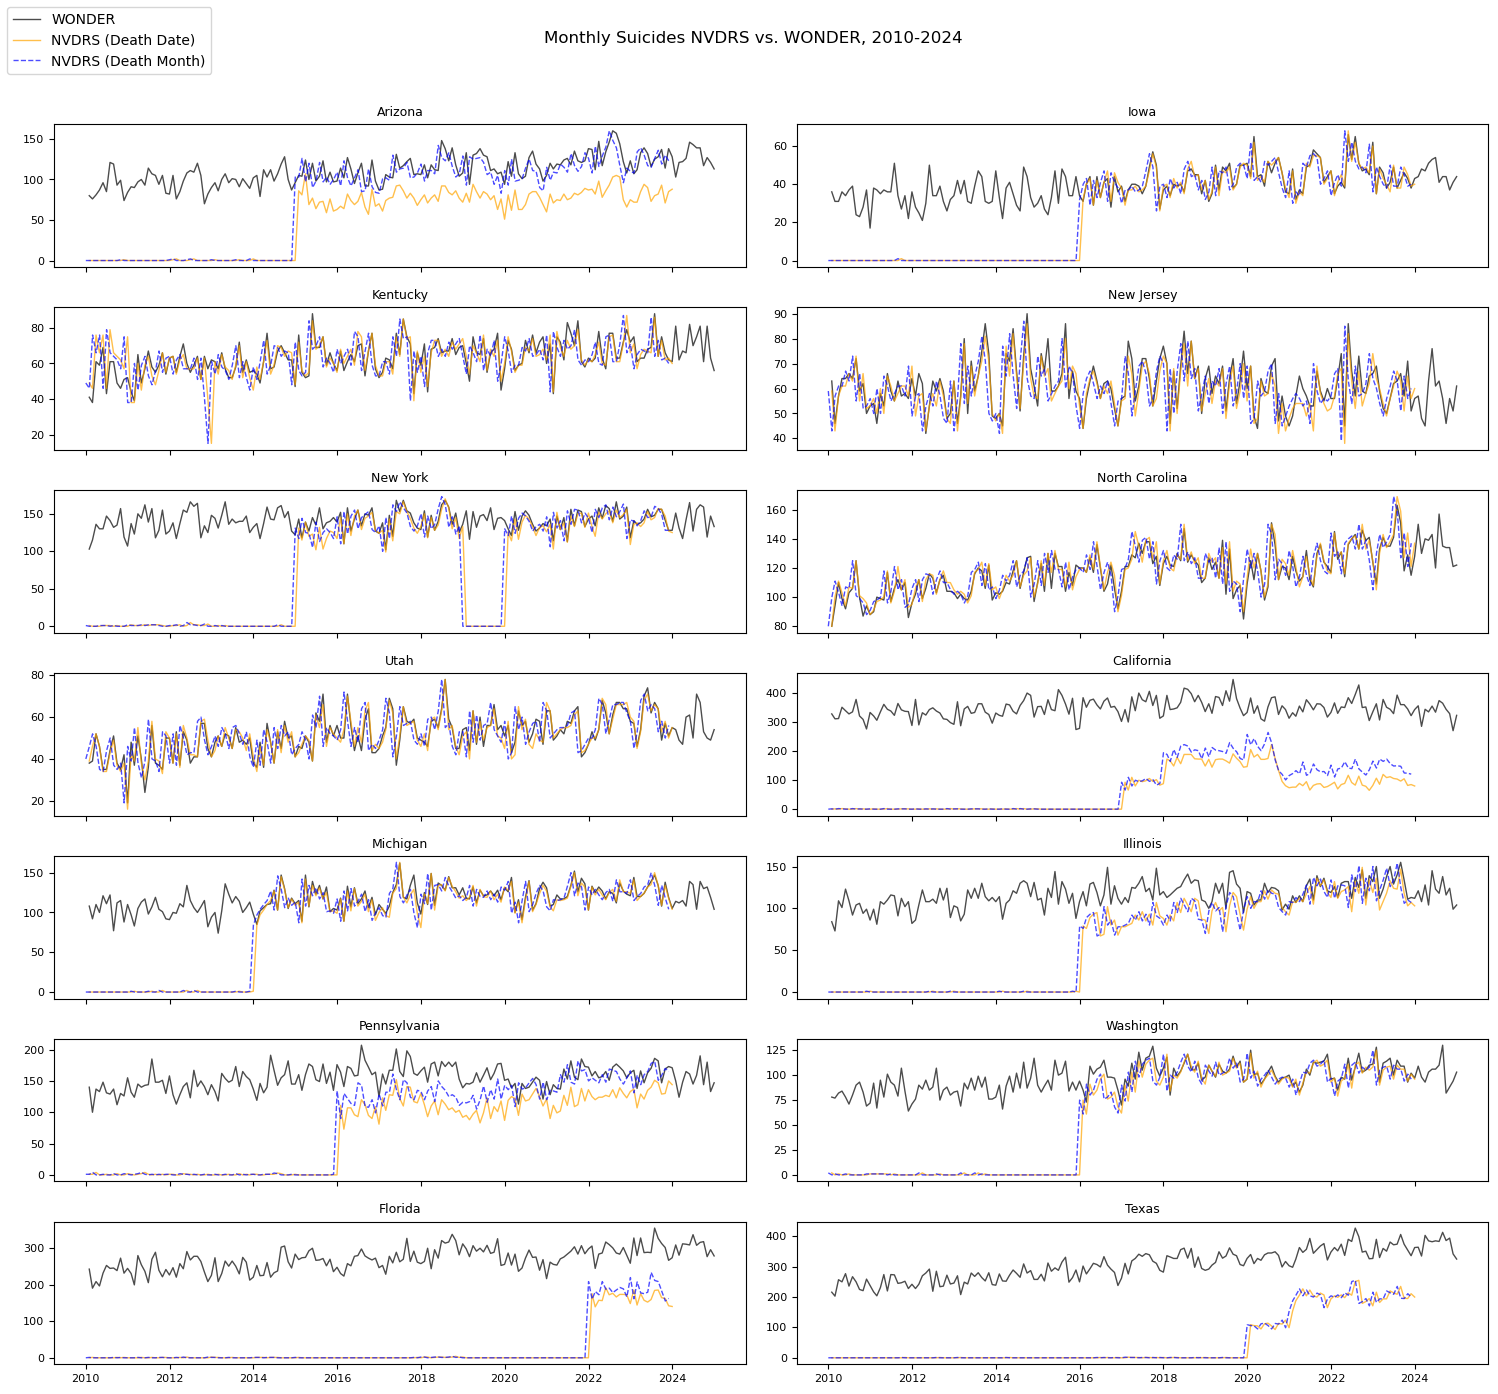

In [11]:
# Define your date range here
start_date = '2010-01-01'
end_date = '2024-12-31'

selected_states = ['Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 'North Carolina', 'Utah']

all_states = selected_states = [
    'Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 'North Carolina', 'Utah', 
    'Alabama', 'Alaska', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 
    'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 
    'Kansas', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 
    'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico', 
    'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 
    'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Vermont', 'Virginia', 
    'Washington', 'West Virginia', 'Wisconsin', 'Wyoming'
]

selected_states = ['Arizona', 'Iowa', 'Kentucky', 'New Jersey', 'New York', 
    'North Carolina', 'Utah','California', 'Michigan', 'Illinois', 'Pennsylvania', 'Washington','Florida', 'Texas']

cols = 2
rows = math.ceil(len(selected_states) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 2*rows), sharex=True)
axes = axes.flatten()

for i, state in enumerate(selected_states):
    ax = axes[i]
    
        # Plot WONDER data
    if state in wnd_df.columns:
        subset_wnd = wnd_df.loc[start_date:end_date]
        ax.plot(subset_wnd.index, subset_wnd[state], color='black', linestyle='-', alpha=0.7, lw=1, label='WONDER' if i==0 else "")

    # Plot NVDRS (Injury) data
    #if state in nvdrs_df_injury.columns:
    #    subset_nvdrs = nvdrs_df_injury.loc[start_date:end_date]
    #    ax.plot(subset_nvdrs.index, subset_nvdrs[state], color='green', linestyle='-', alpha=0.7, lw=1, label='NVDRS (Injury Date)' if i==0 else "")
        
    # Plot NVDRS (Death Date Resampled) data
    if state in nvdrs_df_death.columns:
        subset_nvdrs_death = nvdrs_df_death.loc[start_date:end_date]
        ax.plot(subset_nvdrs_death.index, subset_nvdrs_death[state],color='orange', linestyle='-', alpha=0.7, lw=1, label='NVDRS (Death Date)' if i==0 else "")
        
    # Plot NVDRS (Death Month Direct) data
    if state in nvdrs_df_month.columns:
        subset_nvdrs_month = nvdrs_df_month.loc[start_date:end_date]
        ax.plot(subset_nvdrs_month.index, subset_nvdrs_month[state],color='blue', linestyle='--', alpha=0.7, lw=1, label='NVDRS (Death Month)' if i==0 else "")
        
    ax.set_title(state)
    #ax.set_ylabel('Deaths')



# Remove empty subplots
for j in range(len(selected_states), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Monthly Suicides NVDRS vs. WONDER, 2010-2024', fontsize=12)
fig.legend(loc='upper left')
plt.tight_layout(rect=[0, 0, 1, 0.96])
# Decrease text size for labels and titles across all axes
for ax in axes:
    ax.set_title(ax.get_title(), fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
plt.show()